# <p style="font-family: Cambria; text-align: center; font-size: 44px;">II. DESCRIPTIVE ANALYSIS</p>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("Team2_PythonPioneers_Cardiac_Cleaned_Data.csv")
print(df.shape)

(2008, 210)


In [2]:
# ---------- One colour system for every chart in this notebook ----------
INK, MUTED, GRID = "#1f1f1f", "#6b6b6b", "#e6e6e6"
BLUE    = "#2a78d6"   # single-series bars / histograms, and "Readmission"
ORANGE  = "#eb6834"   # second series, and "Death"
FEMALE, MALE = "#2a78d6", "#eb6834"      # gender always uses these two
REF     = "#d03b3b"   # cut-off / normal-limit reference lines only
NEUTRAL = "#b8b6b0"   # "normal" middle group
# Ordered levels (stages, grades, severity): light blue = better -> dark blue = worse
RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281", "#0d366b"]
def ramp(n):
    """n evenly spaced steps from the blue ramp (light -> dark)."""
    return [RAMP[i] for i in np.linspace(0, len(RAMP) - 1, n).round().astype(int)]
SEQ = LinearSegmentedColormap.from_list("seq", ["#f4f8fd", "#9ec5f4", "#2a78d6", "#0d366b"])

plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#bdbdbd", "axes.labelcolor": INK, "xtick.color": MUTED,
                     "ytick.color": MUTED, "axes.titleweight": "bold", "axes.titlesize": 12,
                     "font.size": 10, "legend.frameon": False})

def label_bars(ax, fmt="{:.1f}%", horizontal=False):
    for c in ax.containers:
        ax.bar_label(c, labels=[fmt.format(v) for v in c.datavalues], padding=3, fontsize=9, color=INK)

def suptitle(fig, text):
    fig.suptitle(text, fontsize=14, fontweight="bold", x=0.06, ha="left", y=1.02)

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q1. How many patients died or were readmitted within 28 days, 3 months and 6 months?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>outcome_during_hospitalization, death_within_28_days / 3_months / 6_months, re_admission_within_28_days / 3_months / 6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>These are the outcome columns of the dataset. Death and readmission after a heart failure admission are the two results hospitals track most, because they show how well patients recover and how much care they need after discharge. Knowing how often they happen gives the baseline for every later question.<b></i></p>

outcome_during_hospitalization
Alive                    1890
DischargeAgainstOrder     107
Dead                       11
Name: count, dtype: int64 

          Readmission  Death
28 days           7.0    1.8
3 months         24.8    2.1
6 months         38.5    2.8


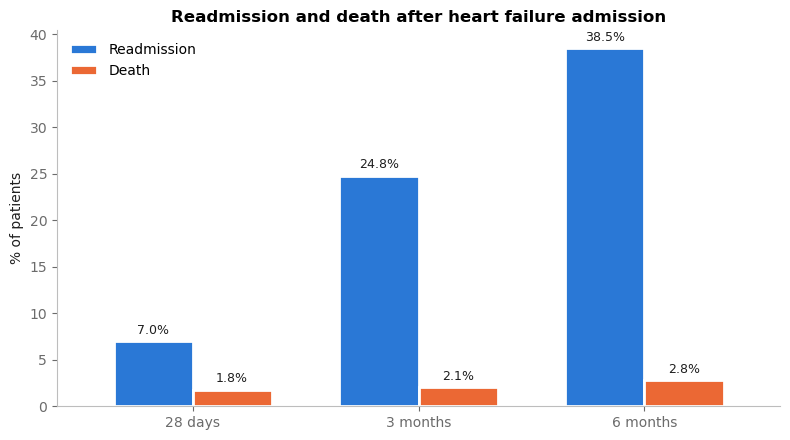

In [3]:
print(df["outcome_during_hospitalization"].value_counts(), "\n")
windows = ["28_days", "3_months", "6_months"]
rates = pd.DataFrame({
    "Readmission": [df[f"re_admission_within_{w}"].mean() * 100 for w in windows],
    "Death":       [df[f"death_within_{w}"].mean() * 100 for w in windows],
}, index=["28 days", "3 months", "6 months"]).round(1)
print(rates)

fig, ax = plt.subplots(figsize=(8, 4.5))
rates.plot(kind="bar", ax=ax, color=[BLUE, ORANGE], rot=0, width=0.7, edgecolor="white", linewidth=2)
label_bars(ax)
ax.set(ylabel="% of patients", title="Readmission and death after heart failure admission")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Only 11 patients (0.5%) died in hospital, and 107 left against medical advice. Death stays low (2.8% by 6 months), but readmission climbs fast: 7% at 28 days, 25% at 3 months and 38.5% at 6 months. In this group of patients, <b>readmission is the bigger problem</b>, and it is the main outcome to explain in the prescriptive and predictive sections.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q2. What is the demographic and body-composition profile of the patients?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>"agecat","gender","weight","height","bmi","bmi_category","obesity_flag"
</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>
The original analysis examined age, gender and BMI because these variables describe the basic demographic profile of the heart-failure population. 
    Since weight and height were cleaned and BMI was recalculated during data cleaning, the analysis can use both the continuous BMI measurement and BMI categories rather than relying only on a categorical BMI variable. 
    xamining these variables together provides a clearer description of the population's age structure, gender composition and body-composition profile.</b></i></p>

Age distribution (%)


,Percent
agecat,
21-29,0.2
29-39,0.6
39-49,2.8
49-59,5.3
59-69,18.3
69-79,35.6
79-89,32.2
89-110,5.0


Gender distribution (%)


,Percent
gender,
Female,57.9
Male,42.1


BMI category distribution (%)


,Percent
bmi_category,
Normal,59.2
Underweight,25.4
Overweight,12.2
Obese,3.3


BMI summary by gender


,patients,median,mean,q1,q3
gender,,,,,
Female,1158,20.56,21.16,18.31,23.43
Male,842,20.81,21.48,18.73,23.52


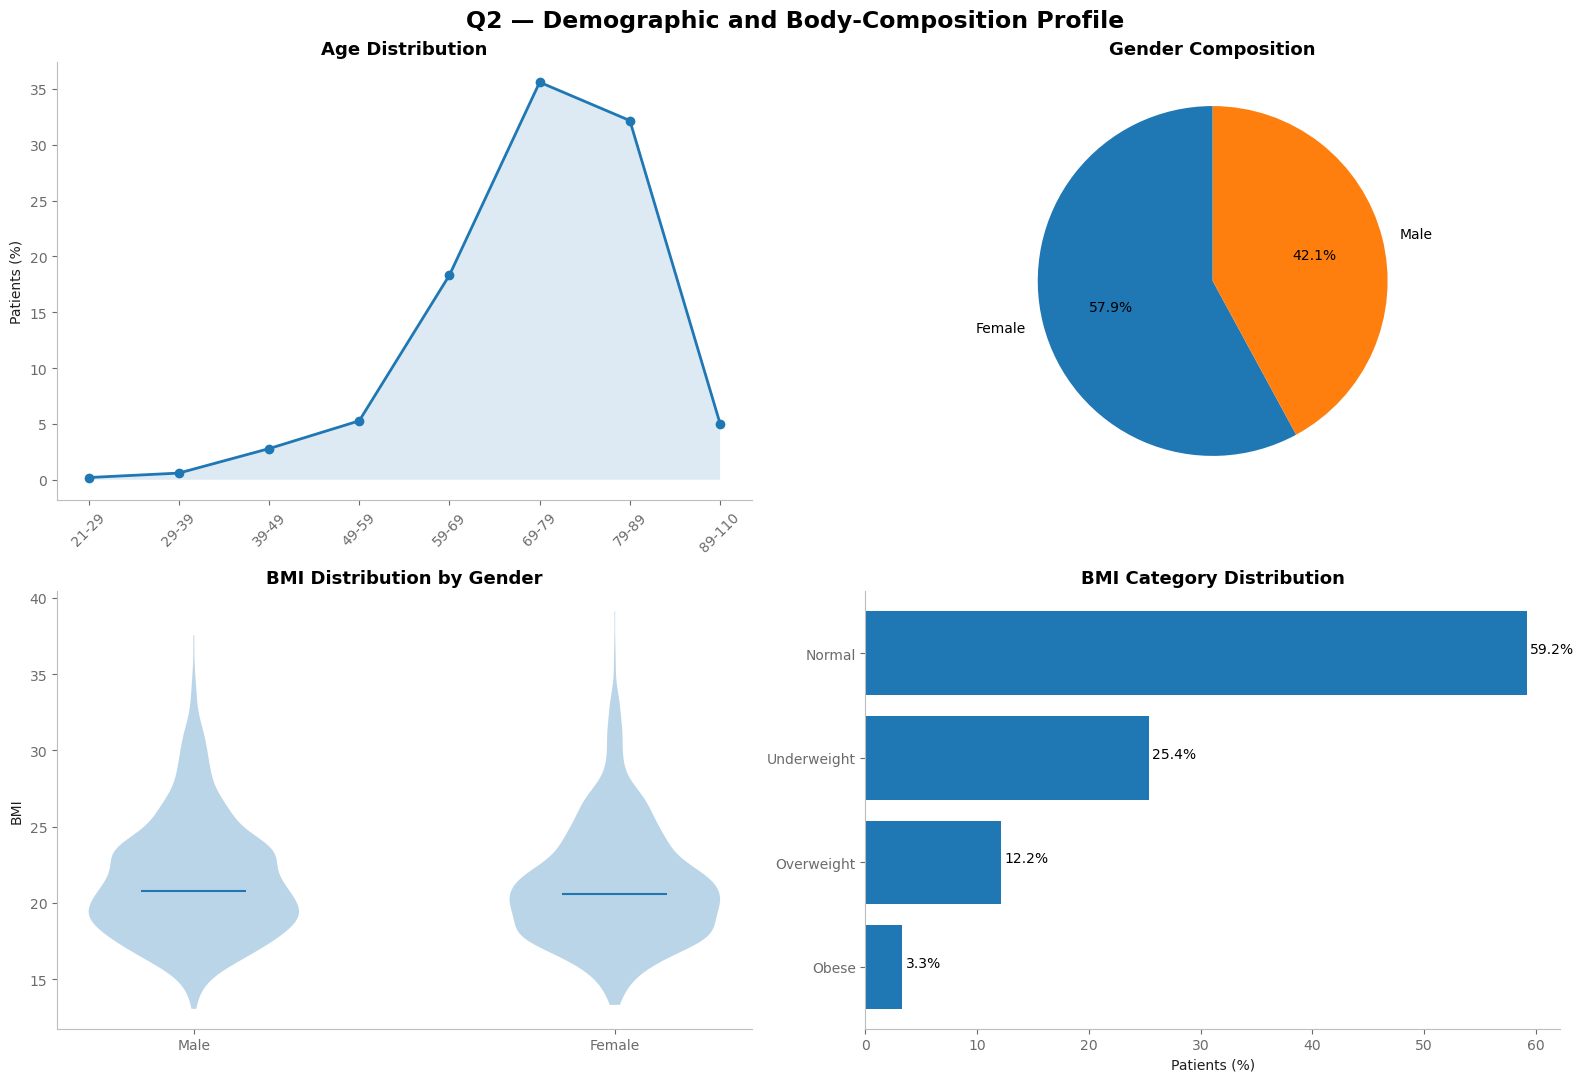

In [4]:
# ============================================================
#  Demographic and Body-Composition Profile
# ============================================================

q2_cols = ["agecat", "gender","weight","height","bmi","bmi_category","obesity_flag"]

q2 = df[q2_cols].copy()

# ------------------------------------------------------------
# 1. Age distribution
# ------------------------------------------------------------

age_order = ["21-29","29-39","39-49","49-59","59-69","69-79","79-89","89-110"]

age_pct = (
    q2["agecat"]
    .value_counts(normalize=True)
    .reindex(age_order)
    .fillna(0)
    * 100
)

# ------------------------------------------------------------
# 2. Gender distribution
# ------------------------------------------------------------

gender_pct = (
    q2["gender"]
    .value_counts(normalize=True)
    * 100
)

# ------------------------------------------------------------
# 3. BMI category distribution
# ------------------------------------------------------------

bmi_category_pct = (
    q2["bmi_category"]
    .value_counts(normalize=True)
    * 100
)

# ------------------------------------------------------------
# 4. BMI distribution by gender
# ------------------------------------------------------------

bmi_gender = [
    q2.loc[
        q2["gender"] == gender,
        "bmi"
    ].dropna()
    for gender in q2["gender"].dropna().unique()
]

gender_labels = q2["gender"].dropna().unique()

# ------------------------------------------------------------
# Display summary tables
# ------------------------------------------------------------

print("Age distribution (%)")
display(age_pct.round(1).to_frame("Percent"))
print("Gender distribution (%)")
display(gender_pct.round(1).to_frame("Percent"))
print("BMI category distribution (%)")
display(bmi_category_pct.round(1).to_frame("Percent"))
print("BMI summary by gender")
display(
    q2.groupby("gender")["bmi"]
    .agg(
        patients="count",median="median",mean="mean",q1=lambda x: x.quantile(0.25),q3=lambda x: x.quantile(0.75))
    .round(2))

# ============================================================
#  visualization 
# Age distribution + BMI distribution + BMI categories
# ============================================================

fig, axes = plt.subplots(2, 2,figsize=(16, 11))

# ------------------------------------------------------------
# A. Age profile
# ------------------------------------------------------------

axes[0, 0].plot(age_pct.index,age_pct.values,marker="o", linewidth=2)
axes[0, 0].fill_between(range(len(age_pct)),age_pct.values, alpha=0.15)
axes[0, 0].set_title("Age Distribution",fontsize=13,fontweight="bold")
axes[0, 0].set_ylabel("Patients (%)")
axes[0, 0].tick_params(axis="x",rotation=45)
# ------------------------------------------------------------
# B. Gender composition
# ------------------------------------------------------------
axes[0, 1].pie(gender_pct.values,labels=gender_pct.index, autopct="%1.1f%%",startangle=90)
axes[0, 1].set_title("Gender Composition", fontsize=13,fontweight="bold")

# ------------------------------------------------------------
# C. BMI distribution by gender
# ------------------------------------------------------------

axes[1, 0].violinplot(bmi_gender, showmedians=True,showextrema=False)
axes[1, 0].set_xticks(range(1, len(gender_labels) + 1), gender_labels)
axes[1, 0].set_ylabel("BMI")
axes[1, 0].set_title( "BMI Distribution by Gender",fontsize=13,fontweight="bold")

# ------------------------------------------------------------
# D. BMI categories
# ------------------------------------------------------------
bmi_category_pct = bmi_category_pct.sort_values( ascending=True)
axes[1, 1].barh( bmi_category_pct.index,bmi_category_pct.values)
axes[1, 1].set_xlabel("Patients (%)")
axes[1, 1].set_title("BMI Category Distribution",fontsize=13, fontweight="bold")
for i, value in enumerate(bmi_category_pct.values):
    axes[1, 1].text(value + 0.3,i, f"{value:.1f}%")

plt.suptitle("Q2 — Demographic and Body-Composition Profile",fontsize=17,fontweight="bold")

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Most patients are elderly: 72.8% are 69 or older, and the largest group is 69–79. There are more women (58%) than men (42%). A quarter of patients (25.4%) are underweight and only 3.3% are obese, so <b>low body weight is a bigger concern than obesity</b> here. This may point to frailty or cardiac cachexia in older patients.<b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q3.How severe is heart failure at admission, and what is the cardiac phenotype of the patient population?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code> "nyha_cardiac_function_classification","killip_grade","type_of_heart_failure","lvef",
    "lvedd_mm"</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>NYHA class (1–4) measures how much the patient's daily activity is limited by symptoms, and Killip grade (1–4) measures signs of congestion and shock, such as fluid in the lungs. Doctors use these two scales to judge how sick a heart failure patient is at admission. Looking at them together shows how many patients are in the severe groups.</b></i></p>

NYHA distribution (%)


,Percentage
nyha_cardiac_function_classification,
2,17.6
3,51.7
4,30.7



Killip distribution (%)


,Percentage
killip_grade,
1,26.2
2,51.2
3,19.5
4,3.0



Type of heart failure (%)


,Percentage
type_of_heart_failure,
Both,73.7
Left,23.8
Right,2.5



LVEF summary


,LVEF
count,635.00
mean,50.68
std,13.22
min,5.00
25%,41.00
50%,51.00
75%,61.00
max,82.00



LVEDD summary


,LVEDD (mm)
count,1309.00
mean,53.19
std,10.74
min,22.00
25%,45.00
50%,53.00
75%,60.00
max,88.00


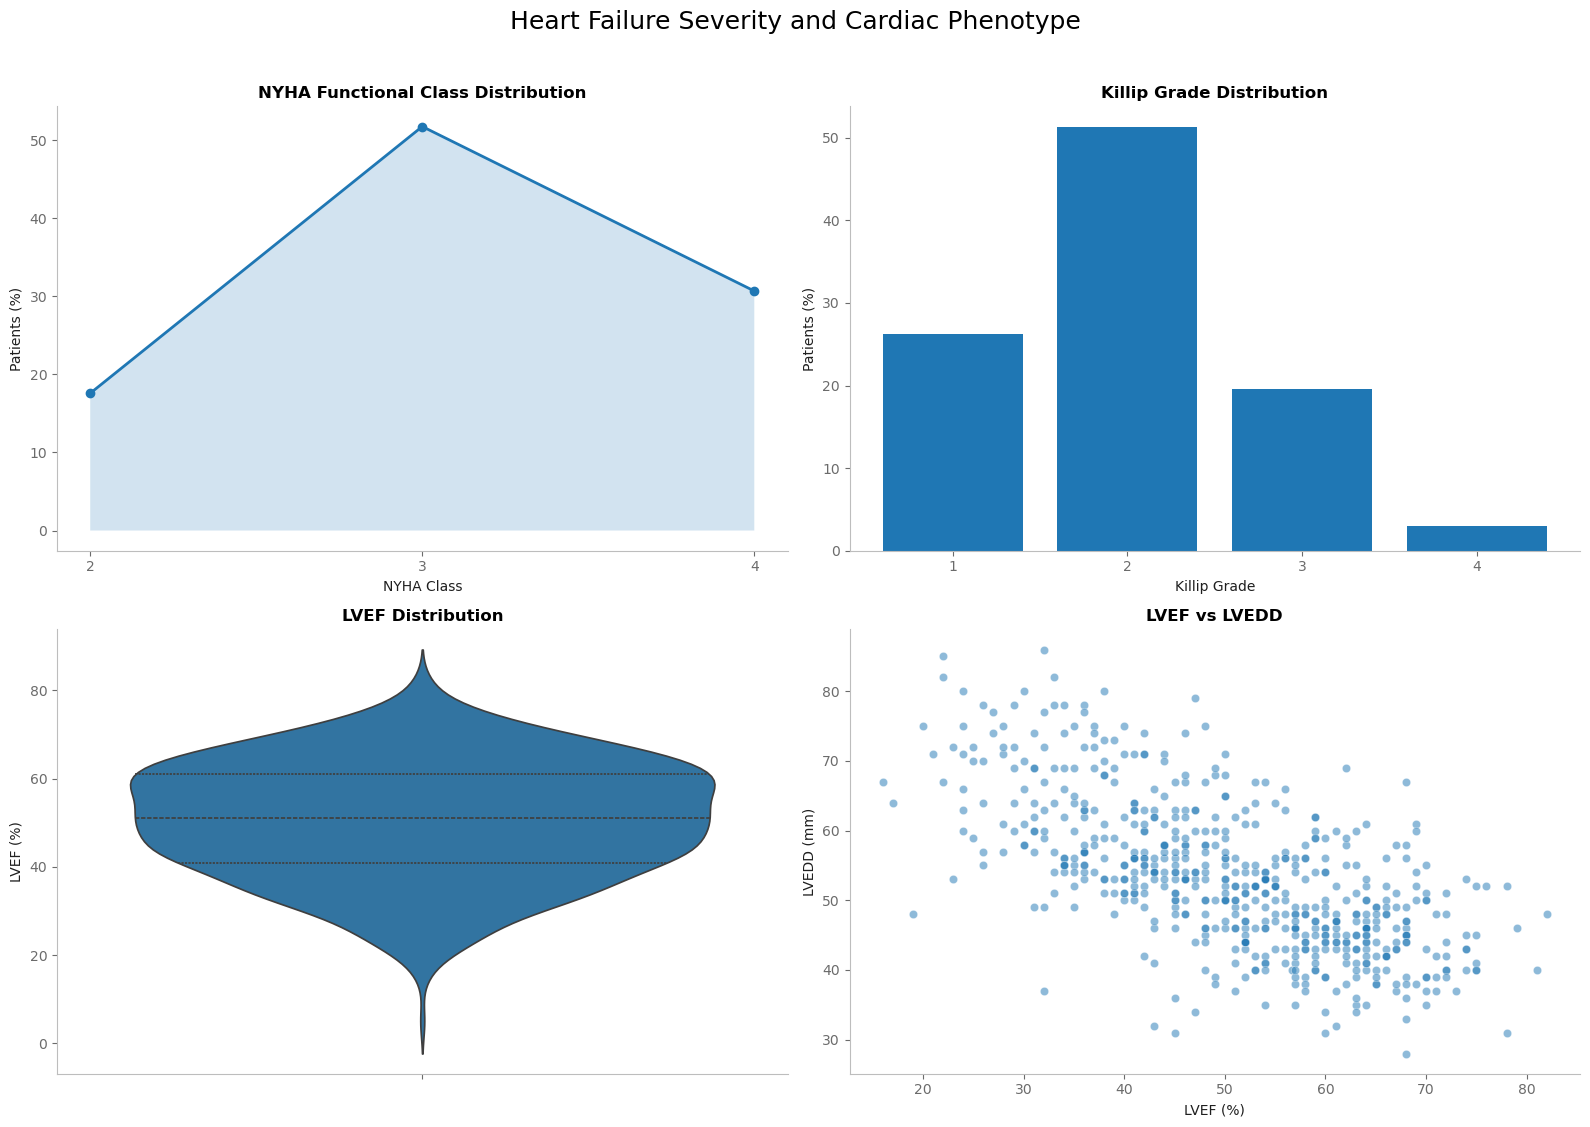


Missingness in cardiac phenotype variables:


,Missing (%)
lvef,68.4
lvedd_mm,34.8
nyha_cardiac_function_classification,0.0
killip_grade,0.0
type_of_heart_failure,0.0


In [5]:
# -----------------------------------------
#  Heart Failure Severity + Cardiac Phenotype
# -----------------------------------------

q3_cols = ["nyha_cardiac_function_classification","killip_grade","type_of_heart_failure","lvef", "lvedd_mm"]

q3 = df[q3_cols].copy()

# -----------------------------
# 1. Severity distributions
# -----------------------------

nyha_pct = (
    q3["nyha_cardiac_function_classification"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .sort_index()
)

killip_pct = (
    q3["killip_grade"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .sort_index()
)

print("NYHA distribution (%)")
display(nyha_pct.round(1).to_frame("Percentage"))

print("\nKillip distribution (%)")
display(killip_pct.round(1).to_frame("Percentage"))


# -----------------------------
# 2. Heart-failure phenotype
# -----------------------------

hf_type_pct = (
    q3["type_of_heart_failure"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
)

print("\nType of heart failure (%)")
display(hf_type_pct.round(1).to_frame("Percentage"))


# -----------------------------
# 3. Cardiac measurements
# -----------------------------

print("\nLVEF summary")
display(
    q3["lvef"]
    .describe()
    .round(2)
    .to_frame("LVEF")
)

print("\nLVEDD summary")
display(
    q3["lvedd_mm"]
    .describe()
    .round(2)
    .to_frame("LVEDD (mm)")
)


# ==========================================
#  VISUALIZATION
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ------------------------------------------
# A. NYHA severity profile
# ------------------------------------------

nyha_plot = nyha_pct.dropna()

axes[0, 0].plot(nyha_plot.index.astype(str), nyha_plot.values,marker="o",linewidth=2)
axes[0, 0].fill_between( range(len(nyha_plot)),nyha_plot.values,alpha=0.2)
axes[0, 0].set_title("NYHA Functional Class Distribution")
axes[0, 0].set_xlabel("NYHA Class")
axes[0, 0].set_ylabel("Patients (%)")

# ------------------------------------------
# B. Killip severity profile
# ------------------------------------------

killip_plot = killip_pct.dropna()

axes[0, 1].bar(killip_plot.index.astype(str),killip_plot.values)
axes[0, 1].set_title("Killip Grade Distribution")
axes[0, 1].set_xlabel("Killip Grade")
axes[0, 1].set_ylabel("Patients (%)")

# ------------------------------------------
# C. LVEF distribution
# ------------------------------------------

lvef_data = q3["lvef"].dropna()
sns.violinplot(y=lvef_data,ax=axes[1, 0],inner="quartile")
axes[1, 0].set_title("LVEF Distribution")
axes[1, 0].set_ylabel("LVEF (%)")
axes[1, 0].set_xlabel("")


# ------------------------------------------
# D. LVEF vs LVEDD
# ------------------------------------------

cardiac_plot = q3[["lvef", "lvedd_mm"]].dropna()
sns.scatterplot(data=cardiac_plot,x="lvef",y="lvedd_mm",alpha=0.5,ax=axes[1, 1])
axes[1, 1].set_title("LVEF vs LVEDD")
axes[1, 1].set_xlabel("LVEF (%)")
axes[1, 1].set_ylabel("LVEDD (mm)")
plt.suptitle("Heart Failure Severity and Cardiac Phenotype", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()


# -----------------------------------------
#  phenotype summary
# -----------------------------------------

print("\nMissingness in cardiac phenotype variables:")
display(
    q3.isna()
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
    .to_frame("Missing (%)")
)

<p style="font-family: Cambria; font-size: 16px;">
<b>Insight</b>
</p>

<p style="font-family: Cambria; font-size: 16px;">
<b><i>
The existing analysis shows that most patients present with advanced heart-failure severity, with approximately 82% classified as NYHA III or IV and a substantial proportion having higher Killip grades. This indicates that the population represents patients with considerable clinical severity at admission.
The cardiac phenotype also shows variation in heart-failure type and ventricular function. LVEF and LVEDD provide complementary information on cardiac function and structure, while the substantial missingness in LVEF should be considered when interpreting the phenotype results.

</i></b>
</p>